# Human MTB chemical-space density clustering

This notebook reads the source workbook without modifying it, removes salts by retaining the largest organic covalent fragment, merges identical desalted parent structures, and performs structural clustering with ECFP4 fingerprints, UMAP, and HDBSCAN. Final region labels are used only in a second, label-guided display UMAP, followed by a deterministic contraction around each region's structural medoid for a compact regional view.

Tautomer standardization, charge neutralization, and acid/base-state normalization are intentionally not performed. Run the cells from top to bottom. The final outputs are one 2D chemical-space image, one overall statistics table, and paginated regional structure-medoid grids; the image outputs are also saved as local PNG files.

## 1. Dependencies and parameters

In [1]:
from __future__ import annotations

import logging
import sys
from collections import Counter
from pathlib import Path
from typing import Any, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap
from IPython.display import Markdown, display
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Draw, rdDepictor
from rdkit.Chem.MolStandardize import rdMolStandardize
from tqdm.auto import tqdm

try:
    from rdkit.Chem import rdFingerprintGenerator
except ImportError:
    rdFingerprintGenerator = None

try:
    import hdbscan as hdbscan_package
    HDBSCAN_BACKEND = 'hdbscan'
    SklearnHDBSCAN = None
except ImportError:
    hdbscan_package = None
    try:
        from sklearn.cluster import HDBSCAN as SklearnHDBSCAN
        HDBSCAN_BACKEND = 'sklearn'
    except ImportError as exc:
        raise ImportError(
            '需要 hdbscan 软件包，或包含 sklearn.cluster.HDBSCAN 的新版 scikit-learn。'
            'Notebook 不会自动安装依赖。'
        ) from exc

if not hasattr(umap, 'UMAP'):
    raise ImportError('当前导入的 umap 不是 umap-learn 软件包。')


INPUT_FILENAME = 'human_mtb_unique_smiles_activity_mean.xlsx'
REQUIRED_COLUMNS = ['Compound ID', 'Canonical SMILES', 'Mean Activity Level']

FP_RADIUS = 2
FP_SIZE = 2048
INCLUDE_CHIRALITY = True

UMAP_N_NEIGHBORS = 50
UMAP_MIN_DIST = 0.05
# 仅用于最终二维展示；越大，同一区域在图上收拢得越明显。
DISPLAY_TARGET_WEIGHT = 0.50
# 最终图保留每个点相对本区域 medoid 的二维距离比例；越小区域越紧凑。
DISPLAY_REGION_CONTRACTION = 0.2
RANDOM_SEED = 42

# 区域合并及噪声补分配使用的最低 ECFP4 Tanimoto 相似度。
# 数值越低，区域越宽泛、最终区域数量通常越少。
REGION_SIMILARITY_THRESHOLD = 0.2
# 任何最终区域都必须至少包含该数量的唯一去盐母体结构。
MIN_REGION_SIZE = 100
MIN_CLUSTER_SIZE = MIN_REGION_SIZE
# 较低的 min_samples 使初始密度核心更包容。
MIN_SAMPLES = 5

# 大区域使用确定性的近似 medoid，避免完整 O(n^2) 计算。
EXACT_MEDOID_MAX_SIZE = 1500
APPROX_MEDOID_MAX_CANDIDATES = 500
APPROX_MEDOID_MAX_REFERENCES = 2000

GRID_COLUMNS = 4
GRID_SUBIMAGE_SIZE = (320, 250)
MAX_MEDOIDS_PER_GRID_IMAGE = 8
OUTPUT_DIRECTORY_NAME = 'human_mtb_clustering_images'
UMAP_IMAGE_FILENAME = 'human_mtb_umap_regions.png'
MEDOID_GRID_FILENAME_PREFIX = 'human_mtb_medoid_grid'
SAVED_IMAGE_DPI = 300
PROGRESS_MIN_INTERVAL = 0.5

_cwd = Path.cwd()
_input_candidates = [
    _cwd / INPUT_FILENAME,
    _cwd / 'tian_datas' / INPUT_FILENAME,
]
INPUT_XLSX = next(
    (path for path in _input_candidates if path.is_file()),
    _input_candidates[-1],
)
OUTPUT_DIRECTORY = INPUT_XLSX.parent / OUTPUT_DIRECTORY_NAME
UMAP_IMAGE_PATH = OUTPUT_DIRECTORY / UMAP_IMAGE_FILENAME

logger = logging.getLogger('human_mtb_similarity_clustering')
logger.handlers.clear()
logger.setLevel(logging.INFO)
logger.propagate = False
_handler = logging.StreamHandler(sys.stdout)
_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(_handler)

# 避免大量 RDKit 警告淹没 Notebook 日志；无效结构仍由质控计数记录。
RDLogger.DisableLog('rdApp.info')
RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')

logger.info('Input workbook: %s', INPUT_XLSX.resolve())
logger.info('Image output directory: %s', OUTPUT_DIRECTORY.resolve())
logger.info('HDBSCAN backend: %s', HDBSCAN_BACKEND)

c:\Users\Nicer117\anaconda3\envs\PDF_Extractor\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-10-01 11:48:05,393 | INFO | Input workbook: C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_unique_smiles_activity_mean.xlsx
2026-10-01 11:48:05,395 | INFO | Image output directory: C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images
2026-10-01 11:48:05,395 | INFO | HDBSCAN backend: hdbscan


## 2. Read, validate, desalt, and merge parent structures

In [2]:
def is_blank(value: Any) -> bool:
    return value is None or pd.isna(value) or (
        isinstance(value, str) and not value.strip()
    )


def read_required_sheets(path: Path) -> tuple[pd.DataFrame, list[str]]:
    if not path.is_file():
        raise FileNotFoundError(f'找不到输入文件：{path.resolve()}')

    sheet_map = pd.read_excel(path, sheet_name=None, engine='openpyxl')
    accepted_frames: list[pd.DataFrame] = []
    accepted_sheet_names: list[str] = []

    for sheet_name, frame in sheet_map.items():
        frame = frame.copy()
        frame.columns = [str(column).strip() for column in frame.columns]
        missing_columns = [
            column for column in REQUIRED_COLUMNS if column not in frame.columns
        ]

        if missing_columns:
            continue

        frame = frame.loc[:, REQUIRED_COLUMNS].copy()
        frame = frame.dropna(how='all', subset=REQUIRED_COLUMNS)
        frame['_Source Sheet'] = sheet_name
        frame['_Source Excel Row'] = np.arange(len(frame), dtype=int) + 2
        accepted_frames.append(frame)
        accepted_sheet_names.append(sheet_name)

    if not accepted_frames:
        raise ValueError(
            '没有工作表同时包含以下列：' + ', '.join(REQUIRED_COLUMNS)
        )

    return pd.concat(accepted_frames, ignore_index=True), accepted_sheet_names


largest_fragment_chooser = rdMolStandardize.LargestFragmentChooser(
    preferOrganic=True
)


def parse_and_desalt(smiles_value: Any) -> tuple[Chem.Mol | None, str | None, bool, str]:
    if is_blank(smiles_value):
        return None, None, False, 'missing'

    smiles = str(smiles_value).strip()
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return None, None, False, 'invalid'

    try:
        fragment_count = len(Chem.GetMolFrags(molecule))
        parent = largest_fragment_chooser.choose(molecule)
        if parent is None or parent.GetNumAtoms() == 0:
            return None, None, fragment_count > 1, 'invalid'

        parent = Chem.Mol(parent)
        Chem.SanitizeMol(parent)
        parent_smiles = Chem.MolToSmiles(
            parent,
            canonical=True,
            isomericSmiles=True,
        )
        return parent, parent_smiles, fragment_count > 1, 'valid'
    except Exception:
        return None, None, False, 'invalid'


logger.info('Reading input workbook...')
raw_data, accepted_sheet_names = read_required_sheets(INPUT_XLSX)
raw_input_rows = len(raw_data)

processed_records: list[dict[str, Any]] = []
missing_smiles_count = 0
invalid_smiles_count = 0
desalted_record_count = 0

for input_order, row in tqdm(
    raw_data.iterrows(),
    total=raw_input_rows,
    desc='1/6 Desalt SMILES',
    unit='row',
    mininterval=PROGRESS_MIN_INTERVAL,
    leave=False,
):
    molecule, parent_smiles, was_desalted, status = parse_and_desalt(
        row['Canonical SMILES']
    )

    if status == 'missing':
        missing_smiles_count += 1
        continue
    if status != 'valid' or molecule is None or parent_smiles is None:
        invalid_smiles_count += 1
        continue

    if was_desalted:
        desalted_record_count += 1

    processed_records.append(
        {
            'Compound ID': row['Compound ID'],
            'Parent SMILES': parent_smiles,
            'Mol': molecule,
            'Mean Activity Level': pd.to_numeric(
                row['Mean Activity Level'], errors='coerce'
            ),
            '_Input Order': int(input_order),
            '_Source Sheet': row['_Source Sheet'],
            '_Source Excel Row': row['_Source Excel Row'],
        }
    )

if not processed_records:
    raise ValueError('没有可用于聚类的有效去盐结构。')

valid_records = pd.DataFrame(processed_records)
valid_source_record_count = len(valid_records)
valid_records['_Compound ID Numeric'] = pd.to_numeric(
    valid_records['Compound ID'], errors='coerce'
)
valid_records = valid_records.sort_values(
    ['_Compound ID Numeric', '_Input Order'],
    kind='stable',
    na_position='last',
)

parent_records: list[dict[str, Any]] = []
_parent_groups = valid_records.groupby('Parent SMILES', sort=False)
for parent_smiles, group in tqdm(
    _parent_groups,
    total=valid_records['Parent SMILES'].nunique(),
    desc='1b/6 Merge parent structures',
    unit='parent',
    mininterval=PROGRESS_MIN_INTERVAL,
    leave=False,
):
    chosen = group.iloc[0]
    group_activity = pd.to_numeric(group['Mean Activity Level'], errors='coerce')
    parent_records.append(
        {
            'Compound ID': chosen['Compound ID'],
            'Parent SMILES': parent_smiles,
            'Mol': Chem.Mol(chosen['Mol']),
            'Mean Activity Level': group_activity.mean(),
            'Merged Source Records': len(group),
        }
    )

parent_data = pd.DataFrame(parent_records).reset_index(drop=True)
collapsed_duplicate_count = valid_source_record_count - len(parent_data)

if len(parent_data) < 3:
    raise ValueError('去盐并合并相同母体后少于 3 个结构，无法进行密度聚类。')

logger.info(
    'QC complete | valid=%d | missing=%d | invalid=%d | desalted=%d | unique parents=%d | collapsed=%d',
    valid_source_record_count,
    missing_smiles_count,
    invalid_smiles_count,
    desalted_record_count,
    len(parent_data),
    collapsed_duplicate_count,
)

2026-10-01 11:48:05,428 | INFO | Reading input workbook...


2026-10-01 11:48:46,414 | INFO | QC complete | valid=41869 | missing=0 | invalid=0 | desalted=756 | unique parents=41840 | collapsed=29


## 3. Fingerprints, 2D embedding, and density regions

In [3]:
def make_fingerprints(molecules: Sequence[Chem.Mol]) -> list[Any]:
    molecule_list = list(molecules)
    if rdFingerprintGenerator is not None:
        generator = rdFingerprintGenerator.GetMorganGenerator(
            radius=FP_RADIUS,
            fpSize=FP_SIZE,
            includeChirality=INCLUDE_CHIRALITY,
        )
        return [
            generator.GetFingerprint(molecule)
            for molecule in tqdm(
                molecule_list,
                desc='2/6 Morgan fingerprints',
                unit='mol',
                mininterval=PROGRESS_MIN_INTERVAL,
            )
        ]

    return [
        AllChem.GetMorganFingerprintAsBitVect(
            molecule,
            radius=FP_RADIUS,
            nBits=FP_SIZE,
            useChirality=INCLUDE_CHIRALITY,
        )
        for molecule in tqdm(
            molecule_list,
            desc='2/6 Morgan fingerprints',
            unit='mol',
            mininterval=PROGRESS_MIN_INTERVAL,
        )
    ]


def fingerprints_to_numpy(fingerprints: Sequence[Any]) -> np.ndarray:
    matrix = np.zeros((len(fingerprints), FP_SIZE), dtype=np.uint8)
    for row_index, fingerprint in tqdm(
        enumerate(fingerprints),
        total=len(fingerprints),
        desc='3/6 Fingerprint matrix',
        unit='fp',
        mininterval=PROGRESS_MIN_INTERVAL,
    ):
        DataStructs.ConvertToNumpyArray(fingerprint, matrix[row_index])
    return matrix


def resolve_cluster_parameters(n_structures: int) -> tuple[int, int]:
    if MIN_CLUSTER_SIZE is None:
        automatic_size = min(100, max(8, round(n_structures * 0.003)))
        min_cluster_size = min(automatic_size, n_structures - 1)
    else:
        min_cluster_size = int(MIN_CLUSTER_SIZE)

    min_cluster_size = max(2, min(min_cluster_size, n_structures - 1))

    if MIN_SAMPLES is None:
        min_samples = max(2, min(15, min_cluster_size // 2))
    else:
        min_samples = int(MIN_SAMPLES)

    min_samples = max(1, min(min_samples, min_cluster_size))
    return min_cluster_size, min_samples


fingerprints = make_fingerprints(parent_data['Mol'].tolist())
fingerprint_matrix = fingerprints_to_numpy(fingerprints)

n_structures = len(parent_data)
effective_neighbors = max(2, min(UMAP_N_NEIGHBORS, n_structures - 1))
clustering_stage_progress = tqdm(
    total=2,
    desc='4-5/6 UMAP + HDBSCAN',
    unit='stage',
    mininterval=PROGRESS_MIN_INTERVAL,
)
logger.info(
    'Fitting 2D UMAP | structures=%d | neighbors=%d | metric=jaccard',
    n_structures,
    effective_neighbors,
)

umap_model = umap.UMAP(
    n_neighbors=effective_neighbors,
    n_components=2,
    min_dist=UMAP_MIN_DIST,
    metric='jaccard',
    random_state=RANDOM_SEED,
    n_jobs=1,
    low_memory=True,
    verbose=True,
)
embedding_2d = umap_model.fit_transform(fingerprint_matrix)
clustering_stage_progress.update(1)

effective_min_cluster_size, effective_min_samples = resolve_cluster_parameters(
    n_structures
)
logger.info(
    'Fitting HDBSCAN | min_cluster_size=%d | min_samples=%d',
    effective_min_cluster_size,
    effective_min_samples,
)

if HDBSCAN_BACKEND == 'hdbscan':
    cluster_model = hdbscan_package.HDBSCAN(
        min_cluster_size=effective_min_cluster_size,
        min_samples=effective_min_samples,
        metric='euclidean',
        cluster_selection_method='eom',
        core_dist_n_jobs=-1,
    )
else:
    cluster_model = SklearnHDBSCAN(
        min_cluster_size=effective_min_cluster_size,
        min_samples=effective_min_samples,
        metric='euclidean',
        cluster_selection_method='eom',
        n_jobs=-1,
    )

raw_cluster_labels = cluster_model.fit_predict(embedding_2d)
clustering_stage_progress.update(1)
clustering_stage_progress.close()
membership_probabilities = getattr(
    cluster_model,
    'probabilities_',
    np.where(raw_cluster_labels >= 0, 1.0, 0.0),
)

# 按区域规模从大到小重新编号，保证 Region 1 是最大区域。
raw_region_counts = Counter(
    int(label) for label in raw_cluster_labels if int(label) >= 0
)
ordered_raw_regions = sorted(
    raw_region_counts,
    key=lambda label: (-raw_region_counts[label], label),
)
region_mapping = {
    raw_label: region_id
    for region_id, raw_label in enumerate(ordered_raw_regions, start=1)
}
region_ids = np.array(
    [region_mapping.get(int(label), -1) for label in raw_cluster_labels],
    dtype=int,
)

parent_data['UMAP 1'] = embedding_2d[:, 0]
parent_data['UMAP 2'] = embedding_2d[:, 1]
parent_data['Region ID'] = region_ids
parent_data['Cluster Probability'] = membership_probabilities

region_count = len(region_mapping)
noise_count = int(np.sum(region_ids == -1))
logger.info(
    'Initial HDBSCAN complete | regions=%d | clustered=%d | noise=%d (%.1f%%)',
    region_count,
    n_structures - noise_count,
    noise_count,
    100.0 * noise_count / n_structures,
)

4-5/6 UMAP + HDBSCAN:   0%|          | 0/2 [00:00<?, ?stage/s]

2026-10-01 11:48:51,239 | INFO | Fitting 2D UMAP | structures=41840 | neighbors=50 | metric=jaccard


c:\Users\Nicer117\anaconda3\envs\PDF_Extractor\lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


UMAP(angular_rp_forest=True, metric='jaccard', min_dist=0.05, n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Thu Oct  1 11:48:51 2026 Construct fuzzy simplicial set
Thu Oct  1 11:48:51 2026 Finding Nearest Neighbors
Thu Oct  1 11:48:51 2026 Building RP forest with 15 trees
Thu Oct  1 11:49:03 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Thu Oct  1 11:50:10 2026 Finished Nearest Neighbor Search
Thu Oct  1 11:50:17 2026 Construct embedding


	completed  0  /  200 epochs


...

Thu Oct  1 11:50:45 2026 Finished embedding


4-5/6 UMAP + HDBSCAN:  50%|█████     | 1/2 [01:54<01:54, 114.23s/stage]

2026-10-01 11:50:45,464 | INFO | Fitting HDBSCAN | min_cluster_size=100 | min_samples=5


4-5/6 UMAP + HDBSCAN: 100%|██████████| 2/2 [01:58<00:00, 59.07s/stage] 

2026-10-01 11:50:49,396 | INFO | Initial HDBSCAN complete | regions=147 | clustered=31807 | noise=10033 (24.0%)


## 4. Select one structural medoid per density region

In [4]:
def select_region_medoid(region_id: int) -> dict[str, Any]:
    member_indices = np.flatnonzero(region_ids == region_id)
    region_size = len(member_indices)

    if region_size <= EXACT_MEDOID_MAX_SIZE:
        candidate_indices = member_indices
        reference_indices = member_indices
        method = 'exact'
    else:
        rng = np.random.default_rng(RANDOM_SEED + region_id)
        probability_order = member_indices[
            np.argsort(-membership_probabilities[member_indices], kind='stable')
        ]
        top_candidate_count = min(
            len(probability_order),
            APPROX_MEDOID_MAX_CANDIDATES // 2,
        )
        top_candidates = probability_order[:top_candidate_count]

        remaining_candidates = np.setdiff1d(
            member_indices,
            top_candidates,
            assume_unique=False,
        )
        random_candidate_count = min(
            len(remaining_candidates),
            APPROX_MEDOID_MAX_CANDIDATES - len(top_candidates),
        )
        random_candidates = (
            rng.choice(
                remaining_candidates,
                size=random_candidate_count,
                replace=False,
            )
            if random_candidate_count
            else np.array([], dtype=int)
        )
        candidate_indices = np.unique(
            np.concatenate([top_candidates, random_candidates])
        )

        reference_count = min(region_size, APPROX_MEDOID_MAX_REFERENCES)
        reference_indices = np.sort(
            rng.choice(
                member_indices,
                size=reference_count,
                replace=False,
            )
        )
        method = 'approximate'

    reference_fingerprints = [fingerprints[index] for index in reference_indices]
    best_index = int(candidate_indices[0])
    best_sample_mean = -1.0

    candidate_progress = tqdm(
        candidate_indices,
        desc=f'R{region_id} medoid candidates',
        unit='candidate',
        mininterval=PROGRESS_MIN_INTERVAL,
        leave=False,
        disable=len(candidate_indices) < 50,
    )
    for candidate_index in candidate_progress:
        similarities = DataStructs.BulkTanimotoSimilarity(
            fingerprints[int(candidate_index)],
            reference_fingerprints,
        )
        sample_mean = float(np.mean(similarities))
        if sample_mean > best_sample_mean + 1e-12:
            best_sample_mean = sample_mean
            best_index = int(candidate_index)

    # 最终紧密度始终使用所选 medoid 与区域内全部结构的精确相似度。
    all_member_fingerprints = [fingerprints[index] for index in member_indices]
    all_similarities = DataStructs.BulkTanimotoSimilarity(
        fingerprints[best_index],
        all_member_fingerprints,
    )
    mean_region_similarity = float(np.mean(all_similarities))

    return {
        'Region ID': region_id,
        'Region Size': region_size,
        'Molecule Index': best_index,
        'Compound ID': parent_data.at[best_index, 'Compound ID'],
        'Mean Activity Level': parent_data.at[best_index, 'Mean Activity Level'],
        'Medoid Mean Tanimoto': mean_region_similarity,
        'Medoid Method': method,
    }


MEDOID_COLUMNS = [
    'Region ID',
    'Region Size',
    'Molecule Index',
    'Compound ID',
    'Mean Activity Level',
    'Medoid Mean Tanimoto',
    'Medoid Method',
]

# 先为 HDBSCAN 初始密度核心选择 medoid，作为区域合并与噪声补分配的锚点。
initial_region_ids = region_ids.copy()
initial_region_values = sorted(int(value) for value in region_mapping.values())
initial_region_count = len(initial_region_values)
initial_noise_count = int(np.sum(initial_region_ids == -1))

initial_medoid_records: list[dict[str, Any]] = []
for initial_region_id in tqdm(
    initial_region_values,
    desc='6a/7 Initial region medoids',
    unit='region',
    mininterval=PROGRESS_MIN_INTERVAL,
):
    initial_medoid_records.append(select_region_medoid(initial_region_id))
initial_medoid_data = pd.DataFrame(initial_medoid_records, columns=MEDOID_COLUMNS)


initial_medoid_indices = {
    int(row['Region ID']): int(row['Molecule Index'])
    for _, row in initial_medoid_data.iterrows()
}

initial_region_sizes = Counter(
    int(region_id) for region_id in initial_region_ids if int(region_id) >= 0
)

# 以较大初始区域的 medoid 为固定锚点合并，避免单链接 A-B-C 链式扩散。
# 被吸收区域必须直接达到锚点阈值；不会因只与另一个被吸收区域相似而并入。
remaining_initial_regions = set(initial_region_values)
anchor_groups: list[tuple[int, list[int]]] = []
with tqdm(
    total=initial_region_count,
    desc='6b/7 Anchor-based region merging',
    unit='region',
    mininterval=PROGRESS_MIN_INTERVAL,
    leave=False,
) as merge_progress:
    while remaining_initial_regions:
        anchor_region = min(
            remaining_initial_regions,
            key=lambda region_id: (-initial_region_sizes[region_id], region_id),
        )
        candidate_regions = sorted(remaining_initial_regions - {anchor_region})
        group_regions = [anchor_region]
        if candidate_regions:
            anchor_fingerprint = fingerprints[initial_medoid_indices[anchor_region]]
            candidate_fingerprints = [
                fingerprints[initial_medoid_indices[region_id]]
                for region_id in candidate_regions
            ]
            candidate_similarities = DataStructs.BulkTanimotoSimilarity(
                anchor_fingerprint,
                candidate_fingerprints,
            )
            group_regions.extend(
                region_id
                for region_id, similarity in zip(
                    candidate_regions, candidate_similarities
                )
                if similarity >= REGION_SIMILARITY_THRESHOLD
            )
        anchor_groups.append((anchor_region, group_regions))
        remaining_initial_regions.difference_update(group_regions)
        merge_progress.update(len(group_regions))

ordered_anchor_groups = sorted(
    anchor_groups,
    key=lambda item: (
        -sum(initial_region_sizes[region_id] for region_id in item[1]),
        item[0],
    ),
)
initial_to_provisional: dict[int, int] = {}
for provisional_id, (_, group_regions) in enumerate(
    ordered_anchor_groups, start=1
):
    for initial_region_id in group_regions:
        initial_to_provisional[initial_region_id] = provisional_id
anchor_group_count = len(ordered_anchor_groups)
provisional_region_ids = np.array(
    [
        initial_to_provisional.get(int(region_id), -1)
        for region_id in initial_region_ids
    ],
    dtype=int,
)

# 将达到最低 Tanimoto 阈值的 HDBSCAN 噪声点补分配到最近的已合并区域。
initial_medoid_fingerprints = [
    fingerprints[initial_medoid_indices[region_id]]
    for region_id in initial_region_values
]
reassigned_noise_count = 0
noise_indices = np.flatnonzero(provisional_region_ids == -1)
for molecule_index in tqdm(
    noise_indices,
    desc='6c/7 Assign eligible noise',
    unit='mol',
    mininterval=PROGRESS_MIN_INTERVAL,
    leave=False,
):
    if not initial_medoid_fingerprints:
        break
    similarities = DataStructs.BulkTanimotoSimilarity(
        fingerprints[int(molecule_index)],
        initial_medoid_fingerprints,
    )
    best_position = int(np.argmax(similarities))
    if similarities[best_position] >= REGION_SIMILARITY_THRESHOLD:
        best_initial_region = initial_region_values[best_position]
        provisional_region_ids[int(molecule_index)] = initial_to_provisional[
            best_initial_region
        ]
        reassigned_noise_count += 1

# 最终执行最低区域规模要求，不足 MIN_REGION_SIZE 的区域重新归为噪声。
provisional_counts = Counter(
    int(region_id) for region_id in provisional_region_ids if int(region_id) >= 0
)
undersized_regions = {
    region_id
    for region_id, count in provisional_counts.items()
    if count < MIN_REGION_SIZE
}
if undersized_regions:
    undersized_mask = np.isin(
        provisional_region_ids,
        np.array(sorted(undersized_regions), dtype=int),
    )
    provisional_region_ids[undersized_mask] = -1

# 按最终区域规模从大到小重新编号为 R1、R2……。
final_counts = Counter(
    int(region_id) for region_id in provisional_region_ids if int(region_id) >= 0
)
ordered_final_regions = sorted(
    final_counts,
    key=lambda region_id: (-final_counts[region_id], region_id),
)
final_region_mapping = {
    old_region_id: new_region_id
    for new_region_id, old_region_id in enumerate(ordered_final_regions, start=1)
}
region_ids = np.array(
    [final_region_mapping.get(int(region_id), -1) for region_id in provisional_region_ids],
    dtype=int,
)
region_count = len(final_region_mapping)
noise_count = int(np.sum(region_ids == -1))
region_mapping = {region_id: region_id for region_id in range(1, region_count + 1)}
parent_data['Region ID'] = region_ids

# 区域合并与补分配完成后，重新计算最终区域的结构 medoid。
medoid_records: list[dict[str, Any]] = []
for region_id in tqdm(
    sorted(region_mapping.values()),
    desc='6d/7 Final region medoids',
    unit='region',
    mininterval=PROGRESS_MIN_INTERVAL,
):
    medoid_records.append(select_region_medoid(region_id))
medoid_data = pd.DataFrame(medoid_records, columns=MEDOID_COLUMNS)

logger.info(
    'Region post-processing complete | initial regions=%d | anchor groups=%d | '
    'final regions=%d | '
    'noise reassigned=%d | final noise=%d (%.1f%%) | min region size=%d | '
    'similarity threshold=%.2f',
    initial_region_count,
    anchor_group_count,
    region_count,
    reassigned_noise_count,
    noise_count,
    100.0 * noise_count / n_structures,
    MIN_REGION_SIZE,
    REGION_SIMILARITY_THRESHOLD,
)

# 区域判定完成后再计算一次仅用于展示的标签引导 UMAP。
# ECFP4/Jaccard 仍提供结构距离；final Region ID 只负责让同一区域在图上靠近。
if region_count > 0:
    logger.info(
        'Fitting label-guided display UMAP | target_weight=%.2f',
        DISPLAY_TARGET_WEIGHT,
    )
    display_stage_progress = tqdm(
        total=1,
        desc='7a/7 Label-guided display UMAP',
        unit='stage',
        mininterval=PROGRESS_MIN_INTERVAL,
    )
    display_umap_model = umap.UMAP(
        n_neighbors=effective_neighbors,
        n_components=2,
        min_dist=UMAP_MIN_DIST,
        metric='jaccard',
        target_metric='categorical',
        target_weight=DISPLAY_TARGET_WEIGHT,
        random_state=RANDOM_SEED,
        n_jobs=1,
        low_memory=True,
        verbose=True,
        init=embedding_2d.copy(),
    )
    embedding_2d = display_umap_model.fit_transform(
        fingerprint_matrix,
        y=region_ids,
    )
    display_stage_progress.update(1)
    display_stage_progress.close()

    # Categorical UMAP 不会主动连接原始特征图中彼此断开的同标签岛屿。
    # 因此仅对最终展示坐标做 medoid 收拢；区域标签和全部统计保持不变。
    uncompacted_display_embedding = embedding_2d.copy()
    compacted_display_embedding = embedding_2d.copy()
    for _, medoid_row in tqdm(
        medoid_data.iterrows(),
        total=len(medoid_data),
        desc='7b/7 Compact regions around medoids',
        unit='region',
        mininterval=PROGRESS_MIN_INTERVAL,
    ):
        display_region_id = int(medoid_row['Region ID'])
        medoid_index = int(medoid_row['Molecule Index'])
        display_region_mask = region_ids == display_region_id
        medoid_coordinate = uncompacted_display_embedding[medoid_index]
        compacted_display_embedding[display_region_mask] = (
            medoid_coordinate
            + DISPLAY_REGION_CONTRACTION
            * (
                uncompacted_display_embedding[display_region_mask]
                - medoid_coordinate
            )
        )
    embedding_2d = compacted_display_embedding
    logger.info(
        'Display regions compacted around structural medoids | retained distance=%.0f%%',
        100.0 * DISPLAY_REGION_CONTRACTION,
    )
else:
    logger.warning(
        'No final region met the minimum size; retaining the unsupervised UMAP.'
    )

parent_data['UMAP 1'] = embedding_2d[:, 0]
parent_data['UMAP 2'] = embedding_2d[:, 1]

6d/7 Final region medoids: 100%|██████████| 46/46 [00:04<00:00,  9.41region/s]

2026-10-01 11:50:57,457 | INFO | Region post-processing complete | initial regions=147 | anchor groups=46 | final regions=46 | noise reassigned=8729 | final noise=1304 (3.1%) | min region size=100 | similarity threshold=0.20


2026-10-01 11:50:57,458 | INFO | Fitting label-guided display UMAP | target_weight=0.50


7a/7 Label-guided display UMAP:   0%|          | 0/1 [00:00<?, ?stage/s]c:\Users\Nicer117\anaconda3\envs\PDF_Extractor\lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


UMAP(angular_rp_forest=True, init=array([[-1.3536258, 8.265786 ],
       [-1.3950244, 8.282322 ],
       [-1.3936285, 8.272595 ],
       ...,
       [ 6.4580207, 11.692462 ],
       [ 5.9401   , 10.900629 ],
       [-8.101648 , 5.964503 ]], dtype=float32), metric='jaccard', min_dist=0.05, n_jobs=1, n_neighbors=50, random_state=42, verbose=True)
Thu Oct  1 11:50:57 2026 Construct fuzzy simplicial set
Thu Oct  1 11:50:58 2026 Finding Nearest Neighbors
Thu Oct  1 11:50:58 2026 Building RP forest with 15 trees
Thu Oct  1 11:51:00 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	Stopping threshold met -- exiting after 3 iterations
Thu Oct  1 11:51:55 2026 Finished Nearest Neighbor Search
Thu Oct  1 11:51:56 2026 Construct embedding


...

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:25]


Thu Oct  1 11:52:22 2026 Finished embedding


7b/7 Compact regions around medoids: 100%|██████████| 46/46 [00:00<00:00, 5110.80region/s]

2026-10-01 11:52:23,252 | INFO | Display regions compacted around structural medoids | retained distance=20%


## Output 1 — Region-compacted, label-guided 2D chemical-space density regions

2026-10-01 11:52:24,759 | INFO | Saved 2D UMAP image: C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_umap_regions.png


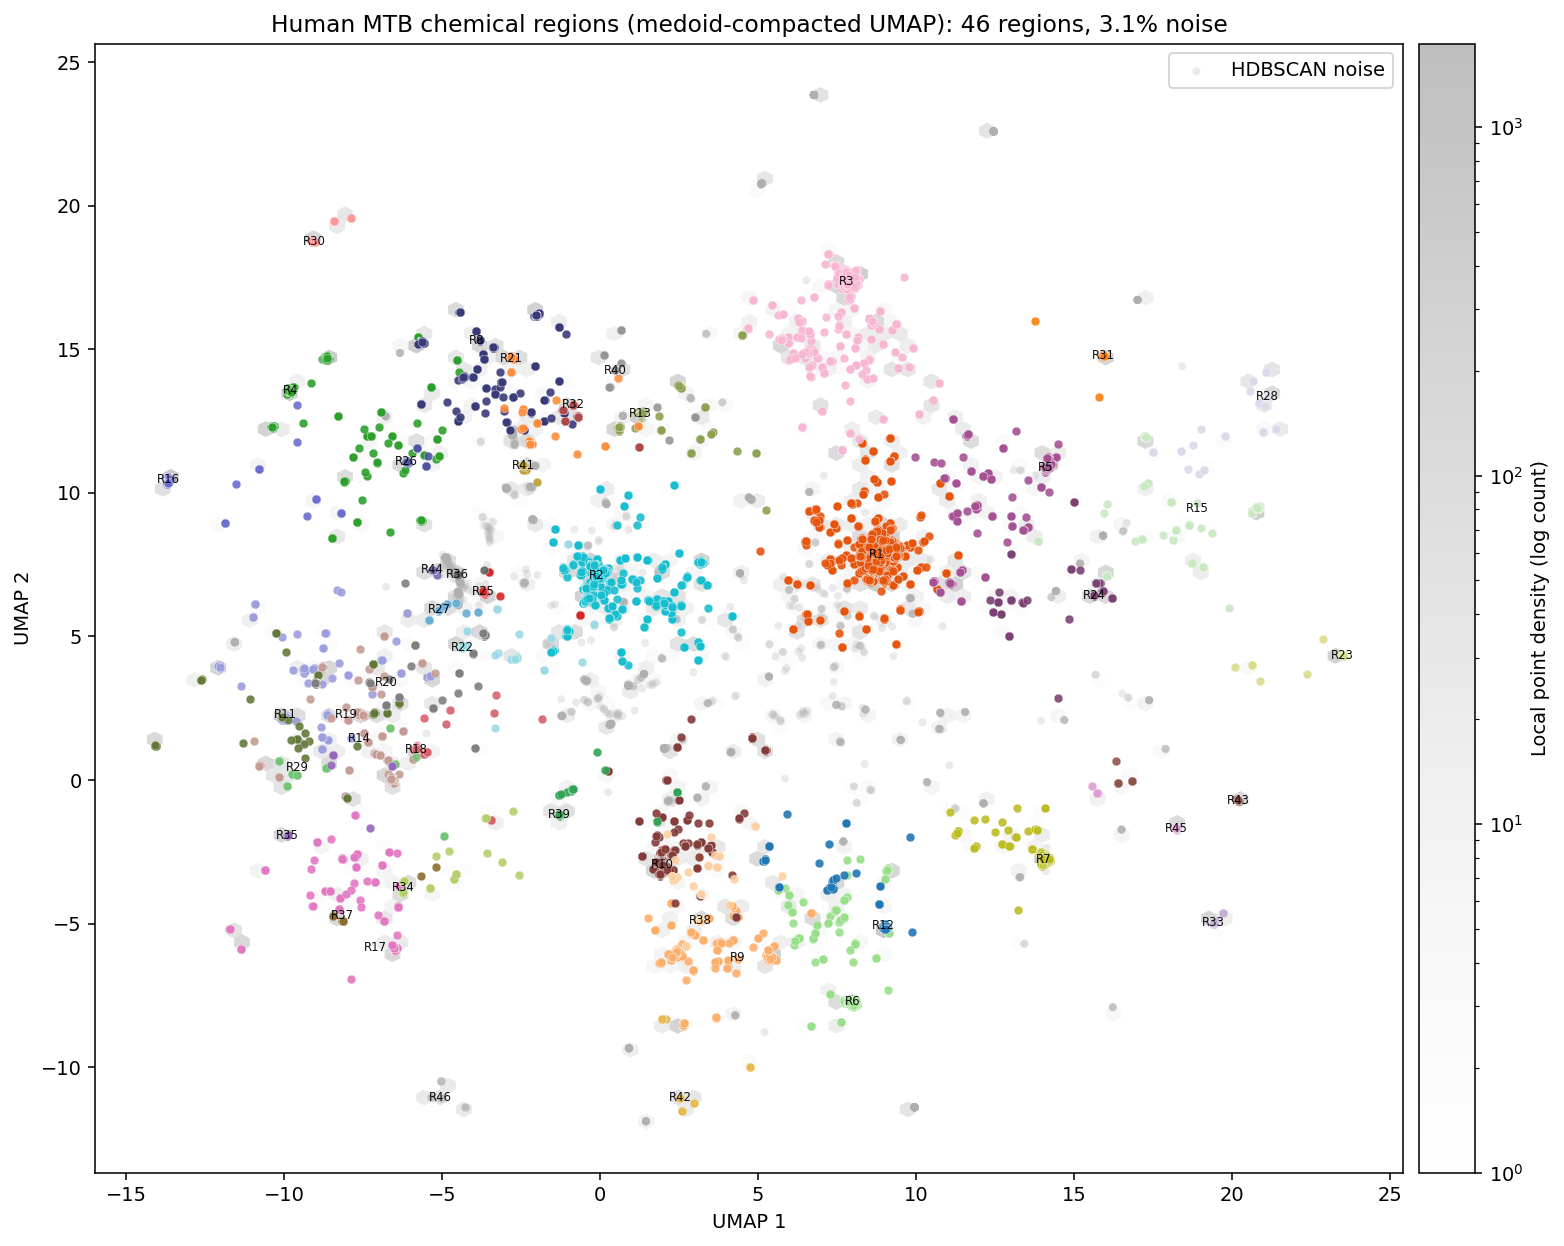

In [5]:
def build_distinct_region_palette(n_colors: int) -> np.ndarray:
    """Select deterministic, maximally separated categorical colors."""
    if n_colors <= 0:
        return np.empty((0, 3), dtype=float)

    base_candidates = np.vstack(
        [
            np.asarray(plt.get_cmap(palette_name).colors, dtype=float)[:, :3]
            for palette_name in ('tab20', 'tab20b', 'tab20c')
        ]
    )
    luminance = base_candidates @ np.array([0.2126, 0.7152, 0.0722])
    color_spread = np.ptp(base_candidates, axis=1)
    vivid_mask = (luminance >= 0.18) & (luminance <= 0.80) & (color_spread >= 0.18)
    candidate_colors = base_candidates[vivid_mask]
    if len(candidate_colors) < n_colors:
        candidate_colors = base_candidates

    selected_indices = [
        int(
            np.argmax(
                np.ptp(candidate_colors, axis=1)
                - np.abs(
                    candidate_colors
                    @ np.array([0.2126, 0.7152, 0.0722])
                    - 0.45
                )
            )
        )
    ]
    while len(selected_indices) < min(n_colors, len(candidate_colors)):
        selected_colors = candidate_colors[selected_indices]
        distances = np.linalg.norm(
            candidate_colors[:, None, :] - selected_colors[None, :, :],
            axis=2,
        )
        minimum_distance = distances.min(axis=1)
        minimum_distance[selected_indices] = -np.inf
        selected_indices.append(int(np.argmax(minimum_distance)))

    selected_colors = candidate_colors[selected_indices]
    if len(selected_colors) < n_colors:
        selected_colors = np.resize(selected_colors, (n_colors, 3))
    return selected_colors[:n_colors]


fig, ax = plt.subplots(figsize=(12, 9), dpi=140)

density_layer = ax.hexbin(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    gridsize=75,
    mincnt=1,
    bins='log',
    cmap='Greys',
    alpha=0.25,
    linewidths=0,
)
density_colorbar = fig.colorbar(density_layer, ax=ax, pad=0.01)
density_colorbar.set_label('Local point density (log count)')

point_size = max(5.0, min(20.0, 5000.0 / np.sqrt(n_structures)))
region_values = sorted(region_mapping.values())
region_colors = build_distinct_region_palette(len(region_values))

noise_mask = region_ids == -1
if np.any(noise_mask):
    ax.scatter(
        embedding_2d[noise_mask, 0],
        embedding_2d[noise_mask, 1],
        s=point_size * 0.85,
        c='#AFAFAF',
        alpha=0.25,
        edgecolors='none',
        rasterized=True,
        zorder=2,
        label='HDBSCAN noise',
    )

for color_index, region_id in enumerate(region_values):
    region_mask = region_ids == region_id
    ax.scatter(
        embedding_2d[region_mask, 0],
        embedding_2d[region_mask, 1],
        s=point_size,
        color=region_colors[color_index],
        alpha=0.90,
        edgecolors='white',
        linewidths=0.15,
        rasterized=True,
        zorder=3,
    )
    region_coordinates = embedding_2d[region_mask]
    label_x = float(np.median(region_coordinates[:, 0]))
    label_y = float(np.median(region_coordinates[:, 1]))
    ax.text(
        label_x,
        label_y,
        f'R{region_id}',
        ha='center',
        va='center',
        fontsize=6,
        weight='normal',
        color='black',
        alpha=0.95,
        zorder=5,
    )

if np.any(noise_mask):
    ax.legend(loc='best', frameon=True)
ax.set_title(
    f'Human MTB chemical regions (medoid-compacted UMAP): {region_count} regions, '
    f'{noise_count / n_structures:.1%} noise'
)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.grid(False)
fig.tight_layout()
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
fig.savefig(
    UMAP_IMAGE_PATH,
    dpi=SAVED_IMAGE_DPI,
    bbox_inches='tight',
    facecolor='white',
)
logger.info('Saved 2D UMAP image: %s', UMAP_IMAGE_PATH.resolve())
plt.show()

## Output 2 — Overall statistics

In [6]:
clustered_count = n_structures - noise_count
region_sizes = [
    int(np.sum(region_ids == region_id)) for region_id in region_values
]
mean_activity = pd.to_numeric(
    parent_data['Mean Activity Level'], errors='coerce'
).mean()

if region_sizes:
    region_size_summary = (
        f'{min(region_sizes)} / {np.median(region_sizes):.1f} / {max(region_sizes)}'
    )
else:
    region_size_summary = '0 / 0 / 0'

statistics_rows = [
    ('Accepted worksheets', len(accepted_sheet_names)),
    ('Input records', raw_input_rows),
    ('Missing SMILES', missing_smiles_count),
    ('Invalid SMILES', invalid_smiles_count),
    ('Records containing multiple fragments', desalted_record_count),
    ('Valid source records', valid_source_record_count),
    ('Unique desalted parent structures', n_structures),
    ('Duplicate parent records merged after desalting', collapsed_duplicate_count),
    ('Initial HDBSCAN regions', initial_region_count),
    ('Final chemical regions', region_count),
    ('Structures assigned to regions', clustered_count),
    ('Noise structures', noise_count),
    ('Noise fraction', f'{noise_count / n_structures:.1%}'),
    ('Region size min / median / max', region_size_summary),
    (
        'Mean activity level of unique parents',
        'NA' if pd.isna(mean_activity) else f'{mean_activity:.4f}',
    ),
    ('Anchor merge Tanimoto threshold', f'{REGION_SIMILARITY_THRESHOLD:.2f}'),
    ('Minimum final region size', MIN_REGION_SIZE),
    ('Display UMAP label weight', f'{DISPLAY_TARGET_WEIGHT:.2f}'),
    (
        'Displayed within-region distance retained',
        f'{DISPLAY_REGION_CONTRACTION:.0%}',
    ),
    ('ECFP4 radius / bits', f'{FP_RADIUS} / {FP_SIZE}'),
    (
        'HDBSCAN min cluster size / min samples',
        f'{effective_min_cluster_size} / {effective_min_samples}',
    ),
]
overall_statistics = pd.DataFrame(
    statistics_rows,
    columns=['Metric', 'Value'],
)
display(overall_statistics)

,Metric,Value
0,Accepted worksheets,1
1,Input records,41869
2,Missing SMILES,0
3,Invalid SMILES,0
4,Records containing multiple fragments,756
5,Valid source records,41869
6,Unique desalted parent structures,41840
7,Duplicate parent records merged after desalting,29
8,Initial HDBSCAN regions,147
9,Final chemical regions,46


## Output 3 — Paginated regional structure-medoid grids (maximum 8 per image)

2026-10-01 11:52:25,662 | INFO | Saved medoid grid page 1/6 | compounds=8 | C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_medoid_grid_01.png


### Medoid grid 1/6

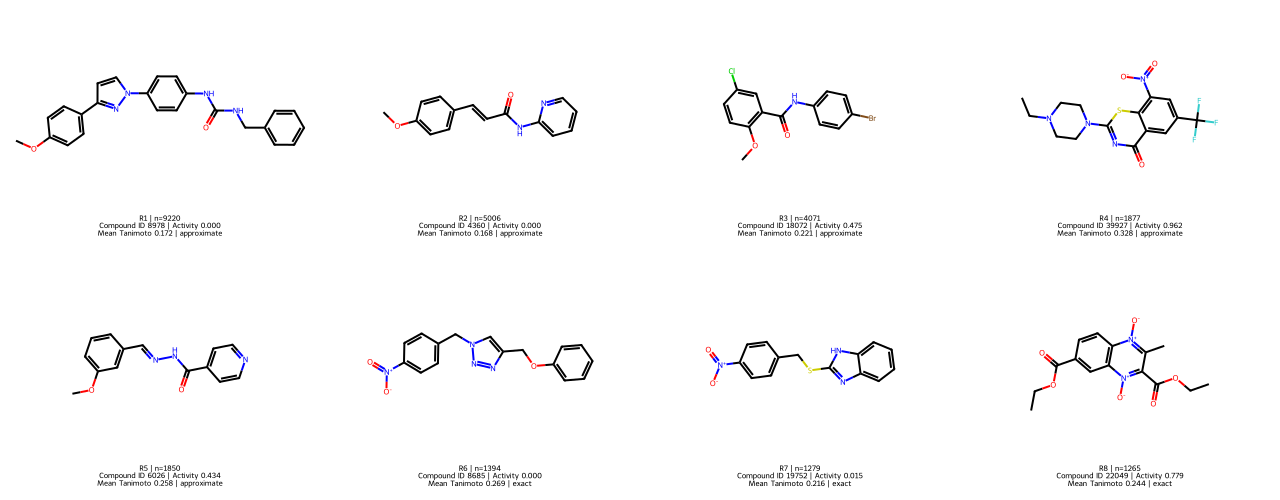

2026-10-01 11:52:25,792 | INFO | Saved medoid grid page 2/6 | compounds=8 | C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_medoid_grid_02.png


### Medoid grid 2/6

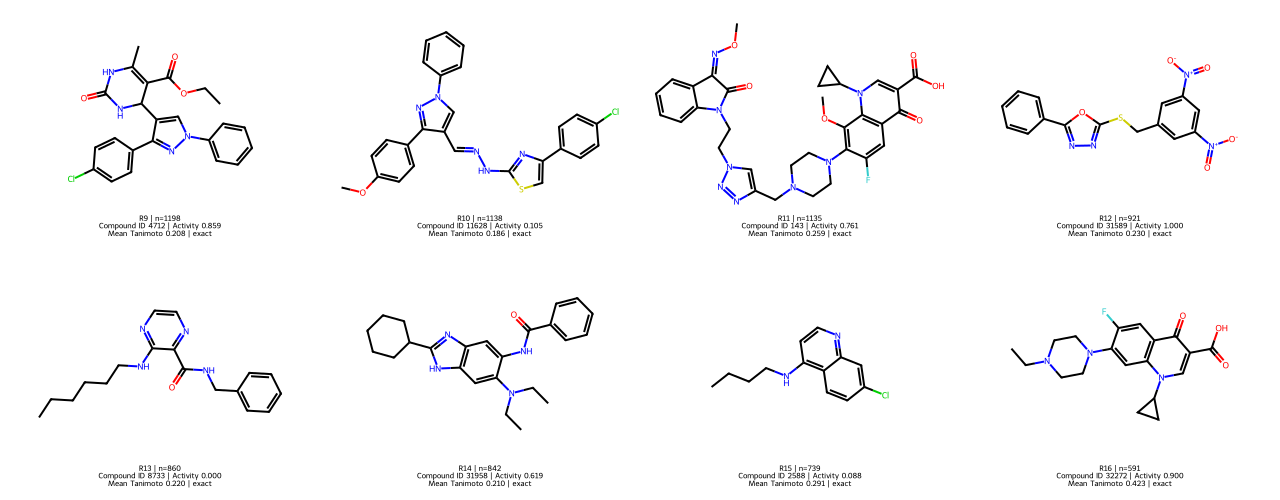

2026-10-01 11:52:25,905 | INFO | Saved medoid grid page 3/6 | compounds=8 | C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_medoid_grid_03.png


### Medoid grid 3/6

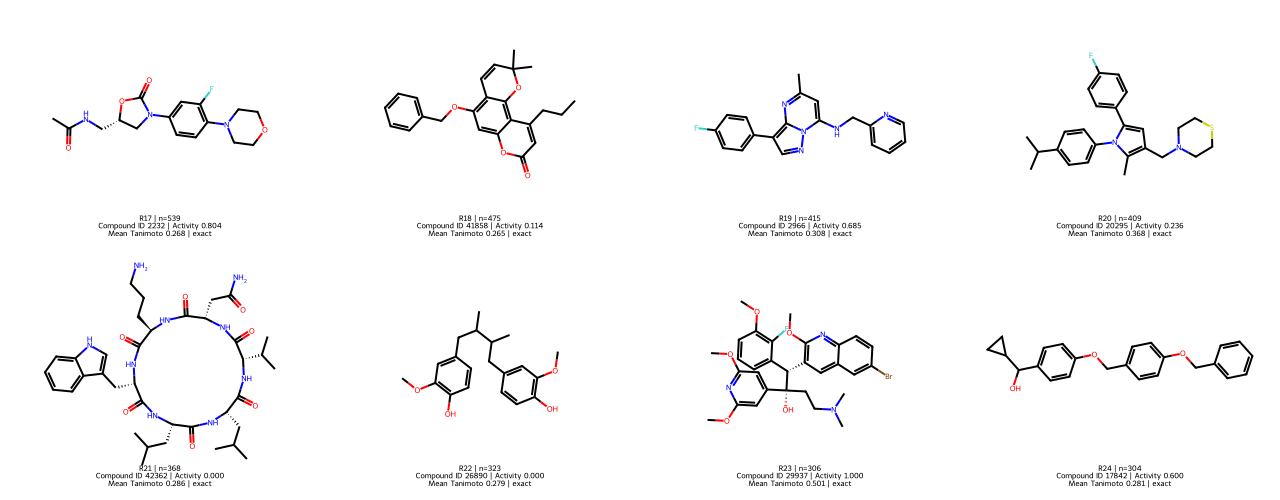

2026-10-01 11:52:26,007 | INFO | Saved medoid grid page 4/6 | compounds=8 | C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_medoid_grid_04.png


### Medoid grid 4/6

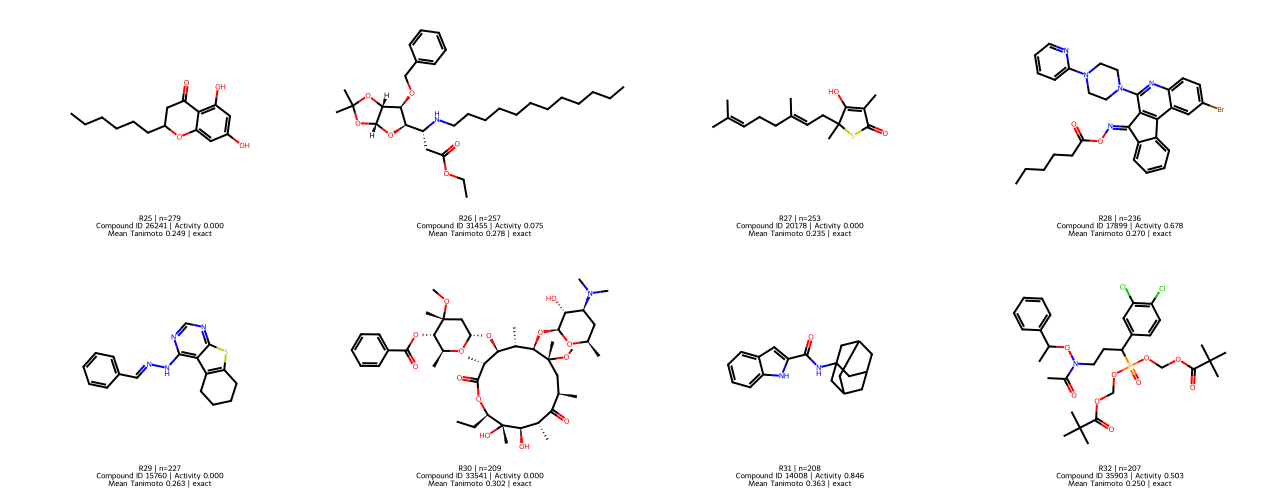

2026-10-01 11:52:26,105 | INFO | Saved medoid grid page 5/6 | compounds=8 | C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_medoid_grid_05.png


### Medoid grid 5/6

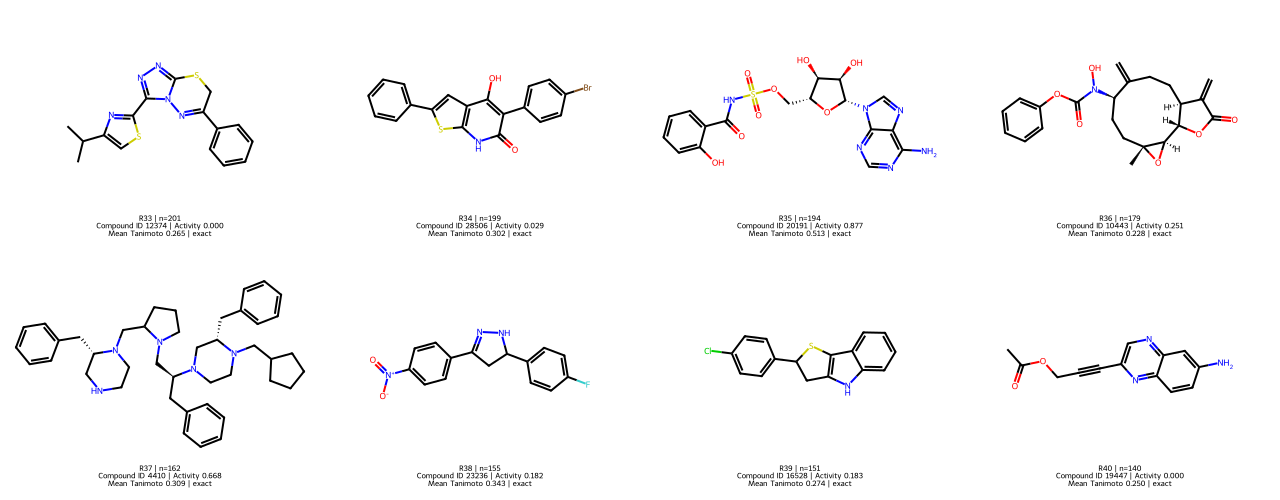

2026-10-01 11:52:26,198 | INFO | Saved medoid grid page 6/6 | compounds=6 | C:\Users\Nicer117\anaconda3\envs\PDF_Extractor\project\tian_datas\origin_datas\human_mtb_clustering_images\human_mtb_medoid_grid_06.png


### Medoid grid 6/6

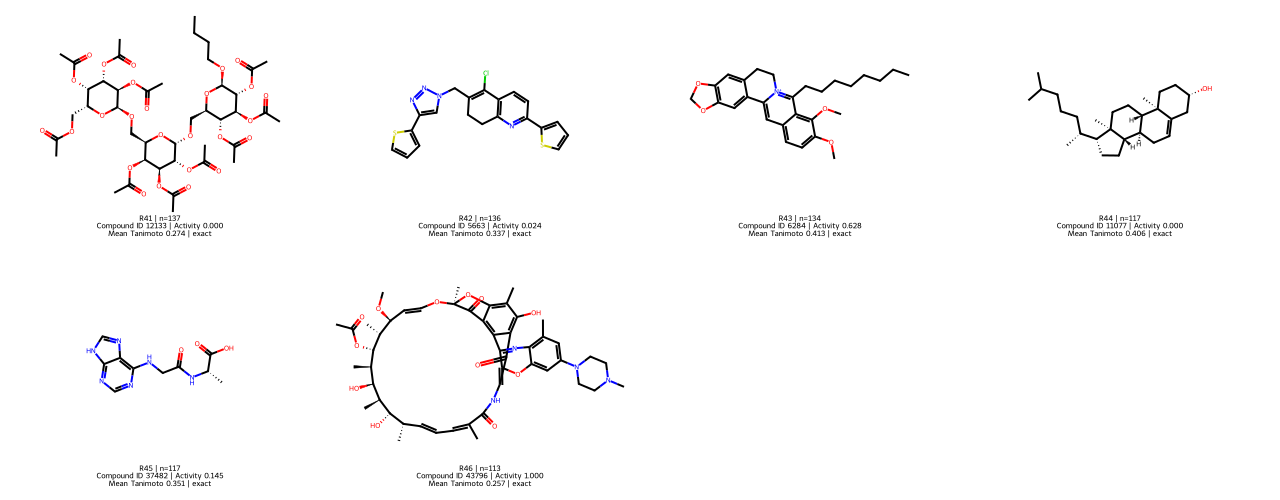

In [7]:
def format_compound_id(value: Any) -> str:
    if is_blank(value):
        return 'NA'
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)) and float(value).is_integer():
        return str(int(value))
    return str(value)


if medoid_data.empty:
    display(
        Markdown(
            '**No medoid grid was generated because HDBSCAN found no density regions.** '
            'Adjust MIN_CLUSTER_SIZE or MIN_SAMPLES and rerun the notebook.'
        )
    )
else:
    grid_molecules: list[Chem.Mol] = []
    grid_legends: list[str] = []

    for _, medoid in medoid_data.sort_values('Region ID').iterrows():
        medoid_index = int(medoid['Molecule Index'])
        molecule = Chem.Mol(parent_data.at[medoid_index, 'Mol'])
        rdDepictor.Compute2DCoords(molecule)
        grid_molecules.append(molecule)

        activity_value = medoid['Mean Activity Level']
        activity_text = (
            'NA' if pd.isna(activity_value) else f'{float(activity_value):.3f}'
        )
        grid_legends.append(
            f"R{int(medoid['Region ID'])} | n={int(medoid['Region Size'])}\n"
            f"Compound ID {format_compound_id(medoid['Compound ID'])} | "
            f"Activity {activity_text}\n"
            f"Mean Tanimoto {float(medoid['Medoid Mean Tanimoto']):.3f} | "
            f"{medoid['Medoid Method']}"
        )

    if MAX_MEDOIDS_PER_GRID_IMAGE < 1:
        raise ValueError('MAX_MEDOIDS_PER_GRID_IMAGE must be at least 1.')

    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    grid_page_count = (
        len(grid_molecules) + MAX_MEDOIDS_PER_GRID_IMAGE - 1
    ) // MAX_MEDOIDS_PER_GRID_IMAGE
    medoid_grid_image_paths: list[Path] = []

    for page_number, page_start in enumerate(
        range(0, len(grid_molecules), MAX_MEDOIDS_PER_GRID_IMAGE),
        start=1,
    ):
        page_end = min(
            page_start + MAX_MEDOIDS_PER_GRID_IMAGE,
            len(grid_molecules),
        )
        page_molecules = grid_molecules[page_start:page_end]
        page_legends = grid_legends[page_start:page_end]
        medoid_grid_image = Draw.MolsToGridImage(
            page_molecules,
            molsPerRow=min(GRID_COLUMNS, len(page_molecules)),
            subImgSize=GRID_SUBIMAGE_SIZE,
            legends=page_legends,
            useSVG=False,
            returnPNG=False,
            maxMols=len(page_molecules),
        )
        medoid_grid_image_path = OUTPUT_DIRECTORY / (
            f'{MEDOID_GRID_FILENAME_PREFIX}_{page_number:02d}.png'
        )
        medoid_grid_image.save(str(medoid_grid_image_path), format='PNG')
        medoid_grid_image_paths.append(medoid_grid_image_path)
        logger.info(
            'Saved medoid grid page %d/%d | compounds=%d | %s',
            page_number,
            grid_page_count,
            len(page_molecules),
            medoid_grid_image_path.resolve(),
        )
        display(Markdown(f'### Medoid grid {page_number}/{grid_page_count}'))
        display(medoid_grid_image)